In [2]:
import pandas as pd

apps_with_duplicates = pd.read_csv("apps.csv")
apps = apps_with_duplicates.drop_duplicates(subset=['App'])
print('Total number of apps in the dataset = ', len(apps))
apps.sample(5)

FileNotFoundError: [Errno 2] No such file or directory: 'apps.csv'

In [3]:
chars_to_remove = ['+', ',', '$']
cols_to_clean = ['Installs', 'Price']

for col in cols_to_clean:
    for char in chars_to_remove:
        apps[col] = apps[col].astype(str).apply(lambda x: x.replace(char, ''))
apps.info()

NameError: name 'apps' is not defined

In [4]:
apps['Installs'] = apps['Installs'].astype(float)
apps['Price'] = apps['Price'].astype(float)
apps.info()

NameError: name 'apps' is not defined

In [5]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.graph_objs as go

num_categories = apps['Category'].nunique()
print('Number of categories = ', num_categories)

num_apps_in_category = apps['Category'].value_counts()

data = [go.Bar(
    x = num_apps_in_category.index,
    y = num_apps_in_category.values
)]

plotly.offline.iplot(data)


NameError: name 'apps' is not defined

In [6]:
avg_app_rating = apps['Rating'].mean()
print('Average app rating = ', avg_app_rating)

data = [go.Histogram(x = apps['Rating'])]

layout = {'shapes': [{
    'type':'line',
    'x0':avg_app_rating,'y0':0,
    'x1':avg_app_rating,'y1':1000,
    'line':{'dash':'dashdot'}
}]}

plotly.offline.iplot({'data':data, 'layout':layout})


NameError: name 'apps' is not defined

In [7]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

apps_with_size_and_rating_present = apps.dropna(subset=['Size','Rating'])

large_categories = apps_with_size_and_rating_present.groupby('Category').filter(lambda x: len(x)>=250)

sns.jointplot(x=large_categories['Size'], y=large_categories['Rating'])

paid_apps = apps[apps['Type'] == 'Paid']
sns.jointplot(x=paid_apps['Price'], y=paid_apps['Rating'])


NameError: name 'apps' is not defined

NameError: name 'apps' is not defined

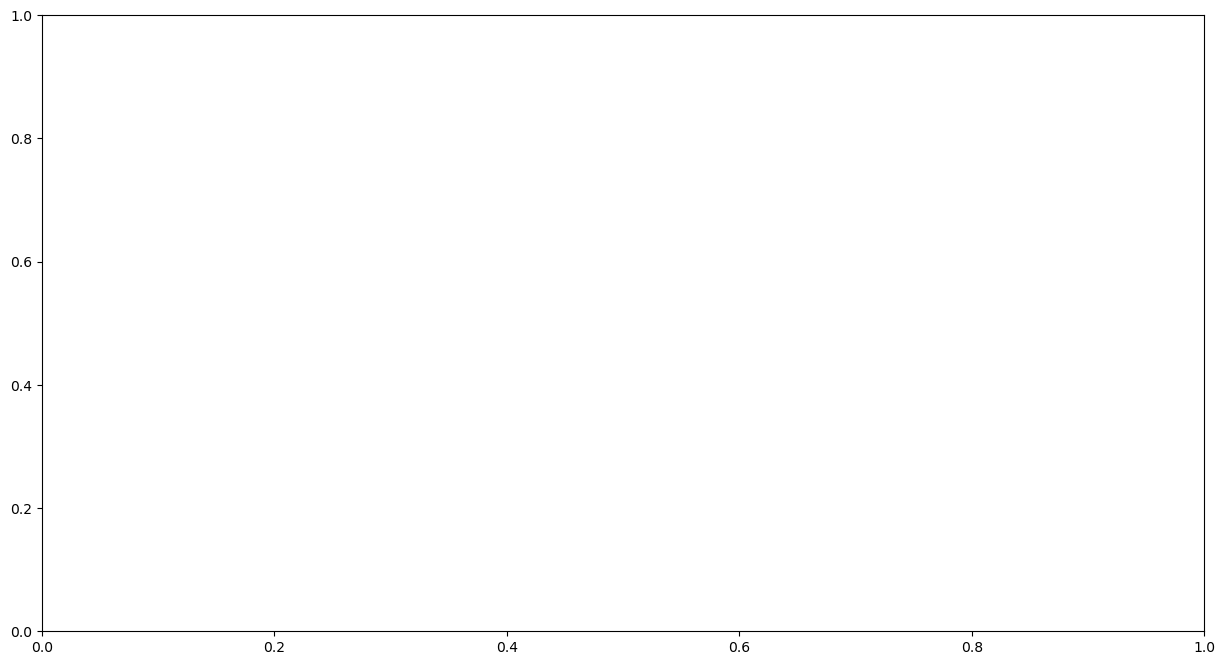

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15,8))

popular_app_cats = apps[apps.Category.isin(['GAME','FAMILY','PHOTOGRAPHY',
                                            'MEDICAL','TOOLS','FINANCE',
                                            'LIFESTYLE','BUSINESS'])]

sns.stripplot(x=popular_app_cats['Category'], y=popular_app_cats['Price'], jitter=True, linewidth=1)
ax.set_title('App pricing trend across categories')

apps_above_200 = apps[apps['Price'] > 200]
apps_above_200[['Category','App','Price']]


In [9]:
apps_under_100 = apps[apps['Price'] < 100]

fig, ax = plt.subplots(figsize=(15,8))
sns.stripplot(x=apps_under_100['Category'], y=apps_under_100['Price'], jitter=True, linewidth=1)
ax.set_title('App pricing trend across categories after filtering junk apps')


NameError: name 'apps' is not defined

In [10]:
trace0 = go.Box(y=apps[apps['Type']=='Paid']['Installs'], name='Paid')
trace1 = go.Box(y=apps[apps['Type']=='Free']['Installs'], name='Free')

layout = go.Layout(
    title="Number of downloads of paid apps vs free apps",
    yaxis=dict(title="Log number of downloads",type='log',autorange=True)
)

plotly.offline.iplot({'data':[trace0,trace1], 'layout':layout})


NameError: name 'apps' is not defined

In [11]:
reviews_df = pd.read_csv("user_reviews.csv")

merged_df = apps.merge(reviews_df, on='App')
merged_df = merged_df.dropna(subset=['Sentiment', 'Review'])

fig, ax = plt.subplots(figsize=(11,8))
sns.boxplot(x=merged_df['Type'], y=merged_df['Sentiment_Polarity'])
ax.set_title('Sentiment Polarity Distribution')


FileNotFoundError: [Errno 2] No such file or directory: 'user_reviews.csv'